C:\Users\25369\AppData\Local\Temp\ipykernel_16116\2982259590.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


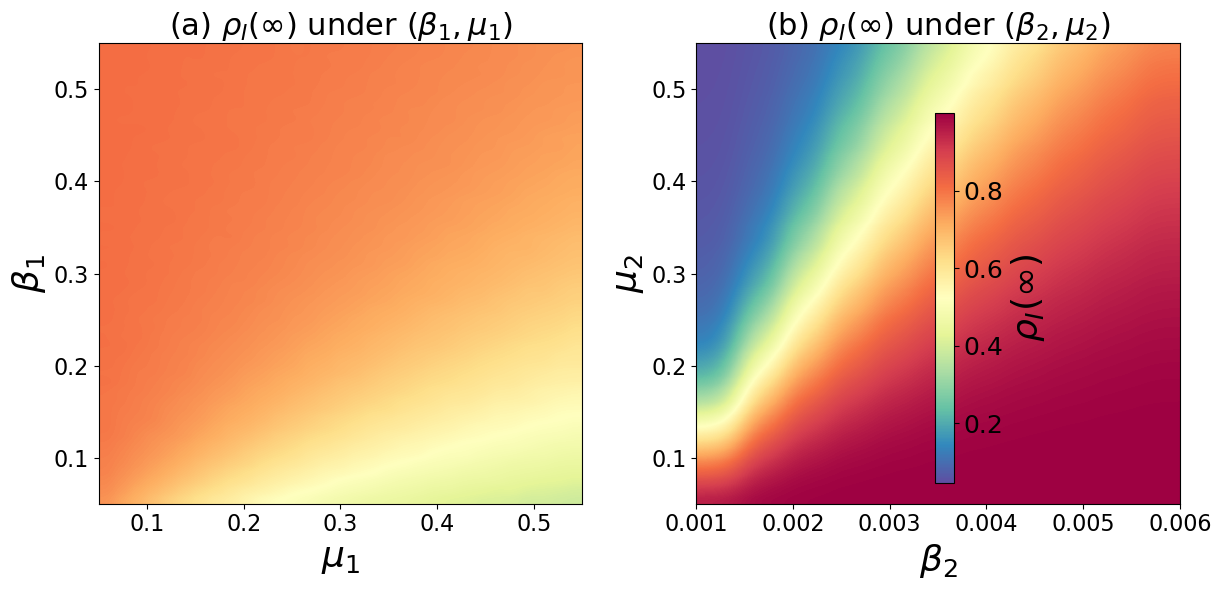

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取CSV文件
def read_heatmap_data(filename):
    """读取CSV并返回矩阵和参数值"""
    df = pd.read_csv(filename, index_col=0)
    matrix = df.values
    row_values = df.index.values.astype(float)  # 第一维参数值
    col_values = df.columns.values.astype(float)  # 第二维参数值
    return matrix, row_values, col_values

# 读取两个热力图数据
matrix_lambda1_mu1, mu1_values, lambda1_values = read_heatmap_data('./test_lambda1_mu1.csv')
matrix_betaU_mu2, mu2_values, beta_U_values = read_heatmap_data('./test_betaU_mu2.csv')
matrix_betaU_lambda1, betaU_values, lambda1_values = read_heatmap_data('./heatmap_lambda1_betaU.csv')

# 1️⃣ 设置统一的颜色范围
vmin = min(matrix_lambda1_mu1.min(), matrix_betaU_mu2.min())
vmax = max(matrix_lambda1_mu1.max(), matrix_betaU_mu2.max())

# 2️⃣ 创建子图（1行2列），共享colorbar
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 横排两张图

# ------------------------
# 第1张图：lambda1 vs mu1
im1 = axs[0].imshow(matrix_lambda1_mu1, cmap='Spectral_r', interpolation='gaussian',
                    extent=[mu1_values.min(), mu1_values.max(), lambda1_values.min(), lambda1_values.max()],
                    origin='lower', aspect='auto', vmin=vmin, vmax=vmax)

axs[0].set_xlabel(r'$\mu_1$', fontsize=26)
axs[0].set_ylabel(r'$\beta_1$', fontsize=26)
axs[0].set_title('(a) ' + r'$\rho_I(\infty)$ under $(\beta_1, \mu_1)$', fontsize=22)
axs[0].tick_params(labelsize=16)

# ------------------------
# 第2张图：beta_U vs mu2
im2 = axs[1].imshow(matrix_betaU_mu2, cmap='Spectral_r', interpolation='gaussian',
                    extent=[beta_U_values.min(), beta_U_values.max(), mu2_values.min(), mu2_values.max()],
                    origin='lower', aspect='auto', vmin=vmin, vmax=vmax)

axs[1].set_xlabel(r'$\beta_2$', fontsize=26)
axs[1].set_ylabel(r'$\mu_2$', fontsize=26)
axs[1].set_title('(b) ' + r'$\rho_I(\infty)$ under $(\beta_2, \mu_2)$', fontsize=22)
axs[1].tick_params(labelsize=16)

# ------------------------
# 添加 colorbar（共享）
cbar = fig.colorbar(im2, ax=axs, orientation='vertical', shrink=0.8, pad=0.02)
cbar.set_label(r'$\rho_I(\infty)$', fontsize=26)
cbar.ax.tick_params(labelsize=18)
cbar.ax.set_title(r'', fontsize=26, pad=10)

plt.tight_layout()
plt.show()
